In [ ]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.datasets import cifar10
import numpy as np
import matplotlib.pyplot as plt
print("Libraries loaded!")

Libraries loaded!


In [ ]:
# Load dataset
(x_train, _),(x_test, _)=cifar10.load_data()

In [ ]:
# Normalize to 0–1 range
x_train=x_train.astype("float32") / 255.0
x_test=x_test.astype("float32") / 255.0
print("Training images:",x_train.shape)
print("Testing images :",x_test.shape)

Training images: (50000, 32, 32, 3)
Testing images : (10000, 32, 32, 3)


In [ ]:
# Add Gaussian Noise
def add_noise(images,noise_factor=0.25):
    noisy=images+noise_factor*np.random.normal(0,1,images.shape)
    noisy=np.clip(noisy, 0., 1.)
    return noisy

# Create noisy datasets
x_train_noisy=add_noise(x_train)
x_test_noisy=add_noise(x_test)

print("Noise added.")

Noise added.


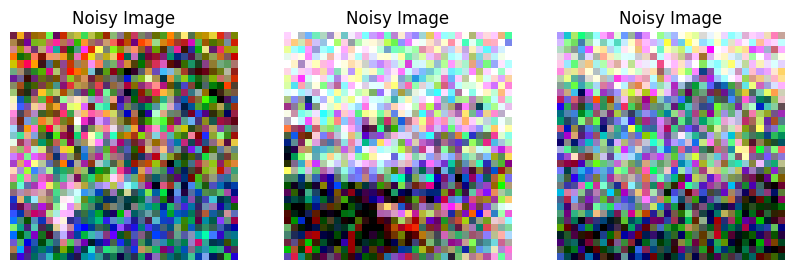

In [ ]:
# Example noisy images
plt.figure(figsize=(10,3))
for i in range(3):
    plt.subplot(1,3,i+1)
    plt.imshow(x_test_noisy[i])
    plt.title("Noisy Image")
    plt.axis("off")
plt.show()

In [ ]:
# CNN Model Architecture

model=Sequential()
# Input shape (32x32 RGB images)
model.add(Conv2D(64, (3,3),activation='relu',padding='same',
                 input_shape=(32,32,3)))
model.add(Conv2D(64, (3,3),activation='relu',padding='same'))
model.add(Conv2D(32, (3,3),activation='relu',padding='same'))
model.add(Conv2D(64, (3,3),activation='relu',padding='same'))

# Final layer outputs RGB image
model.add(Conv2D(3, (3,3),activation='sigmoid',padding='same'))

# Compile the Model
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 3)      │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,411 (302.39 KB)

 Trainable params: 77,411 (302.39 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Model Training
history=model.fit(
    x_train_noisy,x_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_test_noisy,x_test)
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - loss: 0.0118 - val_loss: 0.0053
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0053 - val_loss: 0.0051
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0051 - val_loss: 0.0049
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0049 - val_loss: 0.0049
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0049 - val_loss: 0.0053
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.0049 - val_loss: 0.0048
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.0048 - val_loss: 0.0048
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.0048 - val_loss: 0.0047
Epoch 9/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.0047 - val_loss: 0.0048
Epoch 10/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.0047 - val_loss: 0.0047


In [ ]:
# Make Predictions
predictions=model.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


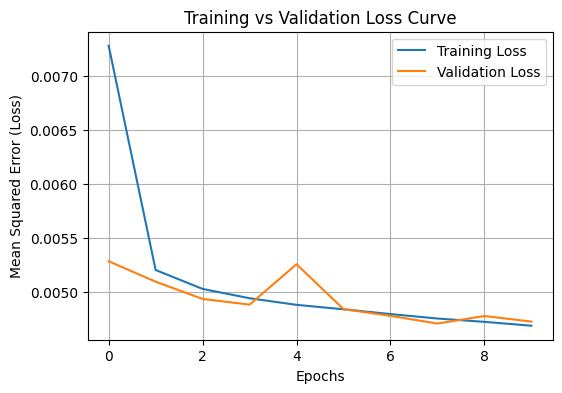

In [ ]:
# Plot Training Loss Curve
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error (Loss)")
plt.title("Training vs Validation Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Compute PSNR and SSIM
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# Choose one image to evaluate
idx=0
original=x_test[idx]
denoised=predictions[idx]

# Calculate PSNR
psnr_value=psnr(original,denoised,data_range=1)

# Calculate SSIM
ssim_value=ssim(
    original,
    denoised,
    channel_axis=2,
    data_range=1
)

print("PSNR:",round(psnr_value, 2), "dB")
print("SSIM:",round(ssim_value, 4))

PSNR: 22.04 dB
SSIM: 0.7565


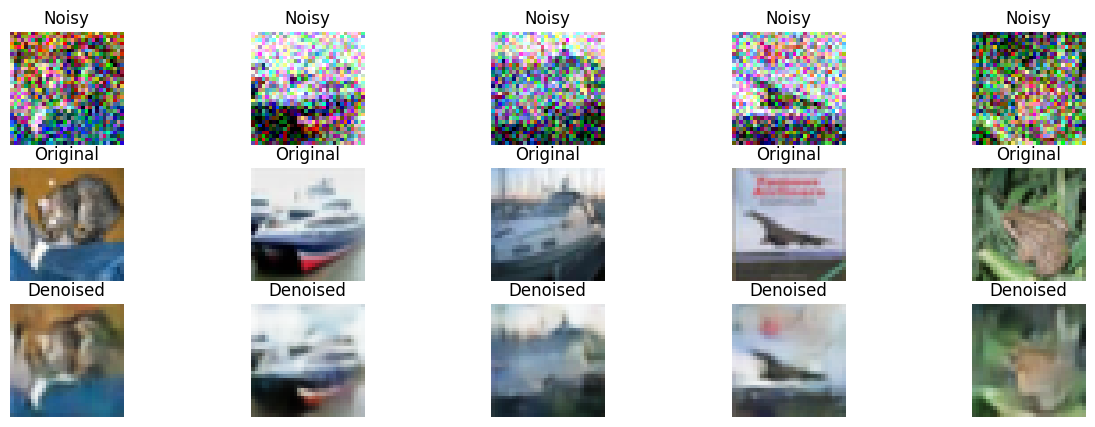

In [ ]:
# Compare Images
n=5
plt.figure(figsize=(15,5))
for i in range(n):
    # Noisy input
    plt.subplot(3,n,i+1)
    plt.imshow(x_test_noisy[i])
    plt.title("Noisy")
    plt.axis("off")
    # Clean Ground Truth
    plt.subplot(3,n,i+n+1)
    plt.imshow(x_test[i])
    plt.title("Original")
    plt.axis("off")
    # CNN Output
    plt.subplot(3,n,i+2*n+1)
    plt.imshow(predictions[i])
    plt.title("Denoised")
    plt.axis("off")
plt.show()